In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('../static/spam_mail.csv')
df.head(5)

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [213]:
df.shape

(5572, 2)

## Data Cleaning

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [215]:
#Missing Values
df.isnull().sum()

Category    0
Masseges    0
dtype: int64

In [216]:
df.sample(5)

,Category,Masseges
5342,spam,u r subscribed 2 TEXTCOMP 250 wkly comp. 1st w...
4091,ham,I remain unconvinced that this isn't an elabor...
4794,ham,Saw Guys and Dolls last night with Patrick Swa...
2458,ham,"Cool, I'll text you when I'm on the way"
5006,ham,Oh k. . I will come tomorrow


In [217]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Category'] = encoder.fit_transform(df['Category'])

In [218]:
df.sample(5)

,Category,Masseges
5531,0,Compliments to you. Was away from the system. ...
3443,0,Yes but I don't care cause I know its there!
1645,0,I.ll post her out l8r. In class
4772,0,Ok then u tell me wat time u coming later lor.
860,0,In work now. Going have in few min.


In [219]:
# Check Duplicates
df.duplicated().sum()

np.int64(403)

In [220]:
# Remove Duplicates
df = df.drop_duplicates(keep='first')

In [221]:
df.duplicated().sum()

np.int64(0)

In [222]:
df.shape

(5169, 2)

## EDA

In [223]:
df.head()

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [224]:
df['Category'].value_counts()

Category
0    4516
1     653
Name: count, dtype: int64

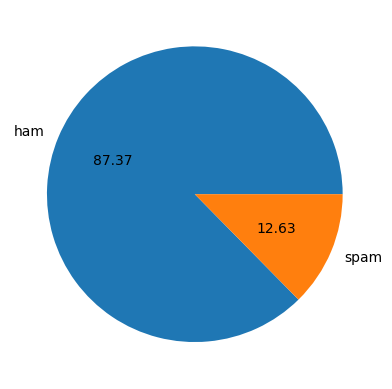

In [225]:
import matplotlib.pyplot as plt
plt.pie(df['Category'].value_counts() , labels=['ham' , 'spam'] , autopct="%0.2f")
plt.show()

In [226]:
# Data is imbalanced

In [227]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shail\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [228]:
df['num_characters'] = df['Masseges'].apply(len)

In [229]:
df.head()

,Category,Masseges,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [230]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

# Num of words
df['Masseges'] = df['Masseges'].astype(str)
df['num_words'] = df['Masseges'].apply(lambda x: len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shail\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [231]:
df.head()

,Category,Masseges,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [232]:
df['num_sentences'] = df['Masseges'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [233]:
df.head()

,Category,Masseges,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [234]:
df[['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [235]:
# ham
df[df['Category'] == 0] [ ['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [236]:
# spam
df[df['Category'] == 1] [ ['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

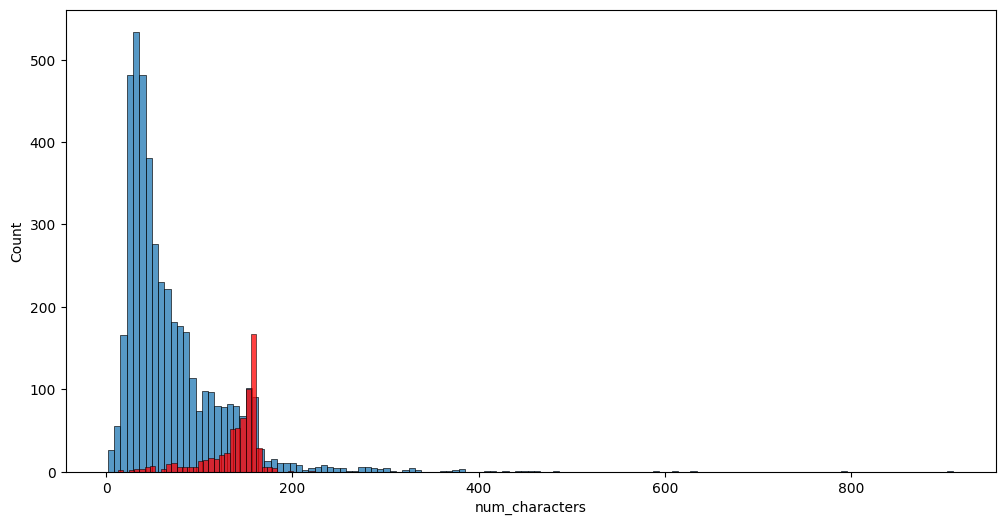

In [237]:
import seaborn as sns
plt.figure(figsize=(12 ,6))
sns.histplot(df[df['Category'] == 0]['num_characters'])
sns.histplot(df[df['Category'] == 1]['num_characters'], color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

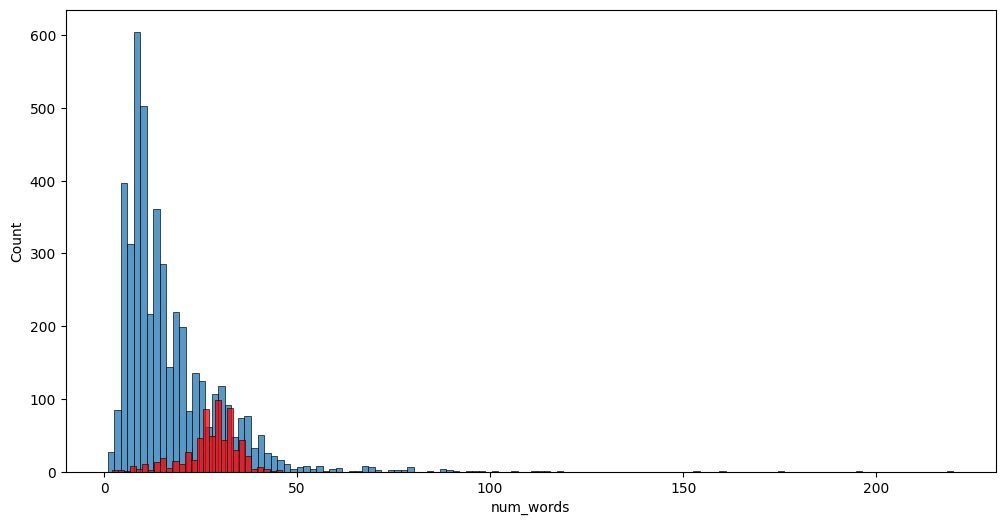

In [238]:
plt.figure(figsize=(12 ,6))
sns.histplot(df[df['Category'] == 0]['num_words'])
sns.histplot(df[df['Category'] == 1]['num_words'], color = 'red')

<Axes: xlabel='num_sentences', ylabel='Count'>

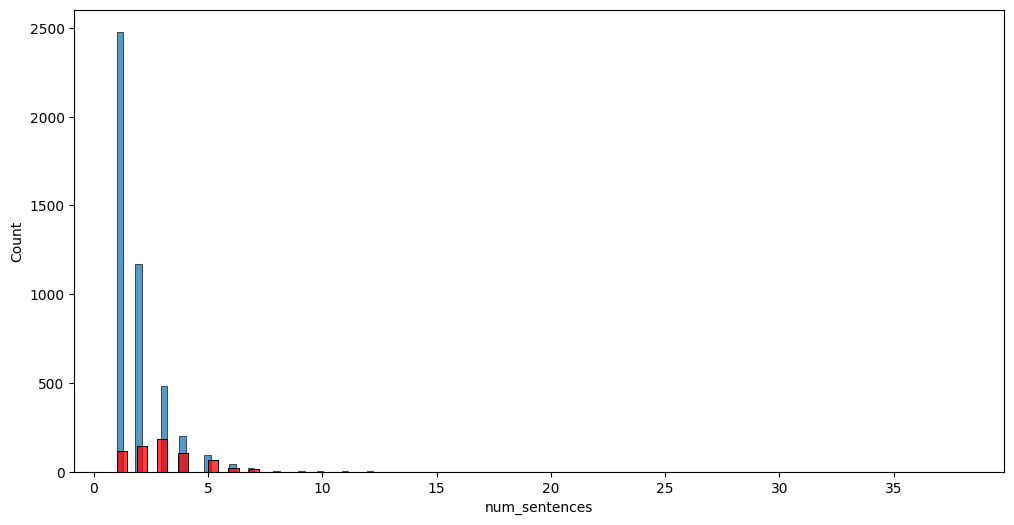

In [239]:
plt.figure(figsize=(12 ,6))
sns.histplot(df[df['Category'] == 0]['num_sentences'])
sns.histplot(df[df['Category'] == 1]['num_sentences'], color = 'red')

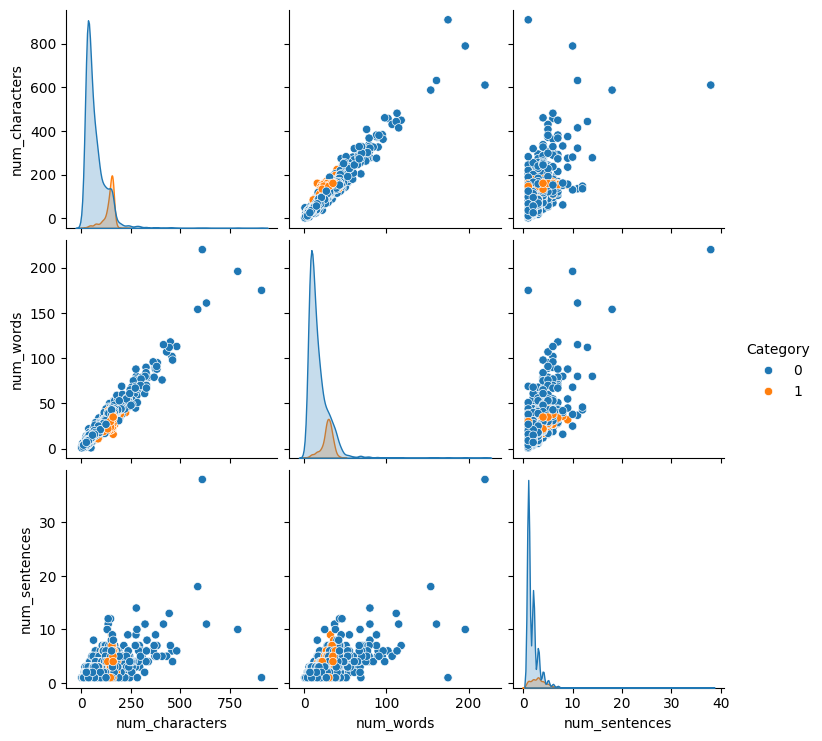

In [240]:
sns.pairplot(df , hue='Category')

In [153]:
# df = df.drop(columns='Masseges') #Beacause corr() shows error for strings.

<Axes: >

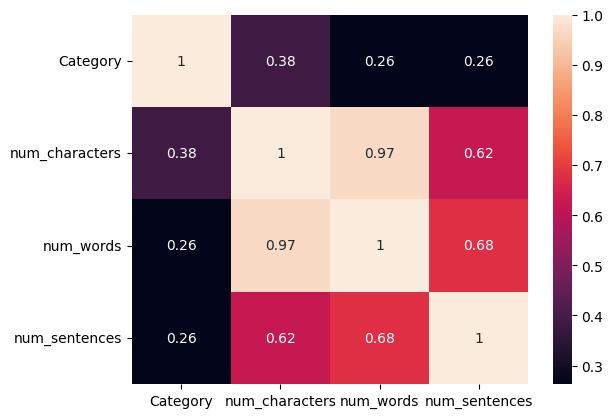

In [241]:
sns.heatmap(df.drop(columns='Masseges').corr(),annot=True)

## Data Preprocessing.

In [242]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
nltk.download('stopwords')

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shail\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [243]:
transform_text(df['Masseges'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [244]:
df['Masseges'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [245]:
df['transform_text']  = df['Masseges'].apply(transform_text)

In [246]:
df.head()

,Category,Masseges,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [247]:
from wordcloud import WordCloud
wc = WordCloud(width=500 , height=500 , min_font_size=10 , background_color='white')

In [248]:
spam_wc = wc.generate(df[df['Category'] == 1]['transform_text'].str.cat(sep=" "))

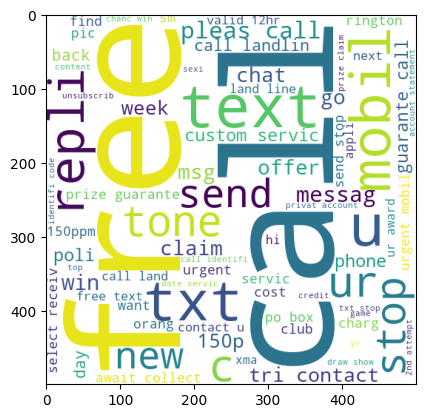

In [249]:
plt.imshow(spam_wc)

In [250]:
ham_wc = wc.generate(df[df['Category'] == 0]['transform_text'].str.cat(sep=" "))

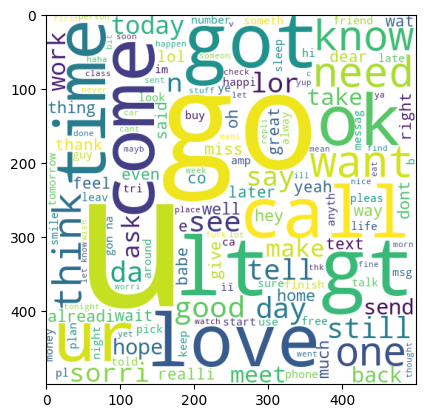

In [251]:
plt.imshow(spam_wc)

In [252]:
df[df['Category']==1]

,Category,Masseges,num_characters,num_words,num_sentences,transform_text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4,freemsg hey darl 3 week word back like fun sti...
8,1,WINNER!! As a valued network customer you have...,158,32,5,winner valu network custom select receivea pri...
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3,mobil 11 month u r entitl updat latest colour ...
11,1,"SIX chances to win CASH! From 100 to 20,000 po...",136,31,3,six chanc win cash 100 pound txt csh11 send co...
...,...,...,...,...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...,90,18,3,want explicit sex 30 sec ring 02073162414 cost...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,38,6,ask 3mobil 0870 chatlin inclu free min india c...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...,160,35,5,contract mobil 11 mnth latest motorola nokia e...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...,147,30,1,remind o2 get pound free call credit detail gr...


In [253]:
spam_corpus = []
for msg in df[df['Category']==1]['transform_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


In [254]:
len(spam_corpus)

9939

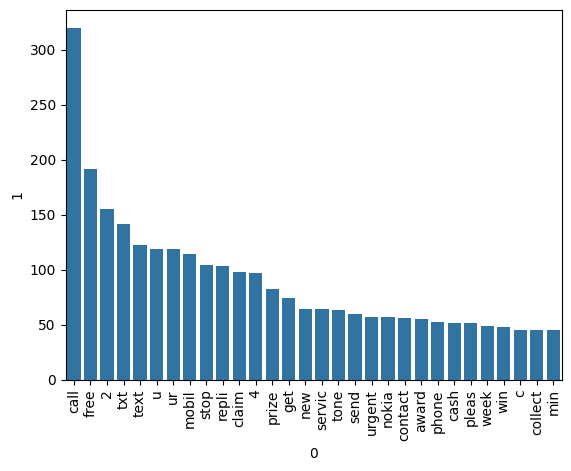

In [255]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] , y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [256]:
ham_corpus = []
for msg in df[df['Category']==0]['transform_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [257]:
len(ham_corpus)

35404

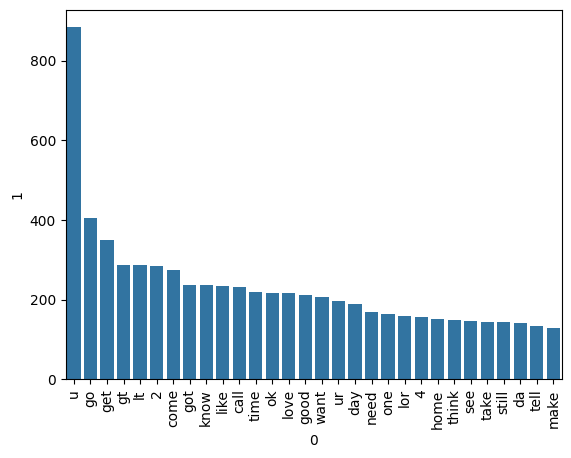

In [258]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0] , y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

## Model Building.

In [259]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfTransformer
tfidf = TfidfTransformer()
cv = CountVectorizer()

In [260]:
X = cv.fit_transform(df['transform_text'])
X = tfidf.fit_transform(X).toarray()

In [261]:
X.shape

(5169, 6708)

In [262]:
y = df['Category'].values

In [263]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [264]:
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=2)

In [ ]:
# from sklearn.naive_bayes import GaussianNB , MultinomialNB , BernoulliNB
# gnb = GaussianNB()
# mnb = MultinomialNB()
# bnb = BernoulliNB()

In [ ]:
# gnb.fit(X_train , y_train)
# y_pred1 = gnb.predict(X_test)
# print(accuracy_score(y_test , y_pred1))
# print(confusion_matrix(y_test , y_pred1))
# print(precision_score(y_test , y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [ ]:
# mnb.fit(X_train , y_train)
# y_pred1 = mnb.predict(X_test)
# print(accuracy_score(y_test , y_pred1))
# print(confusion_matrix(y_test , y_pred1))
# print(precision_score(y_test , y_pred1))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [209]:
# bnb.fit(X_train , y_train)
# y_pred1 = bnb.predict(X_test)
# print(accuracy_score(y_test , y_pred1))
# print(confusion_matrix(y_test , y_pred1))
# print(precision_score(y_test , y_pred1))

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.svm import SVC
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier

In [ ]:
# svc = SVC(kernel='sigmoid', gamma=1.0)
# knc = KNeighborsClassifier()
# mnb = MultinomialNB()
# dtc = DecisionTreeClassifier(max_depth=5)
# lrc = LogisticRegression(solver='liblinear', penalty='l1')
# rfc = RandomForestClassifier(n_estimators=50, random_state=2)
# abc = AdaBoostClassifier(n_estimators=50, random_state=2)
# bc = BaggingClassifier(n_estimators=50, random_state=2)
# etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
# gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
# xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
# clfs = {
#     'SVC' : svc,
#     'KN' : knc,
#     'NB': mnb,
#     'DT': dtc,
#     'LR': lrc,
#     'RF': rfc,
#     'AdaBoost': abc,
#     'BgC': bc,
#     'ETC': etc,
#     'GBT': gbdt,
#     'xgb': xgb
# }

In [ ]:
# def train_classifier(clf, X_train, y_train, X_test, y_test):
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict(X_test)
#     accuracy = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     return accuracy, precision

# train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9729206963249516, 0.9741379310344828)

In [ ]:
# accuracy_scores = []
# precision_scores = []

# for name, clf in clfs.items():
#     current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
#     print("For ", name)
#     print("Accuracy - ", current_accuracy)
#     print("Precision - ", current_precision)
#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8380952380952381
For  LR
Accuracy -  0.9516441005802708
Precision -  0.94
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8409090909090909
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  GBT
Accuracy -  0.9526112185686654
Precision -  0.9238095238095239
For  xgb
Accuracy -  0.9748549323017408
Precision -  0.9516129032258065


In [ ]:
# performance_df = pd.DataFrame({'Algorithm' :clfs.keys(), 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Precision' , ascending=False)

In [ ]:
# performance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,xgb,0.974855,0.951613
4,LR,0.951644,0.940000
9,GBT,0.952611,0.923810
7,BgC,0.958414,0.862595
6,AdaBoost,0.924565,0.840909


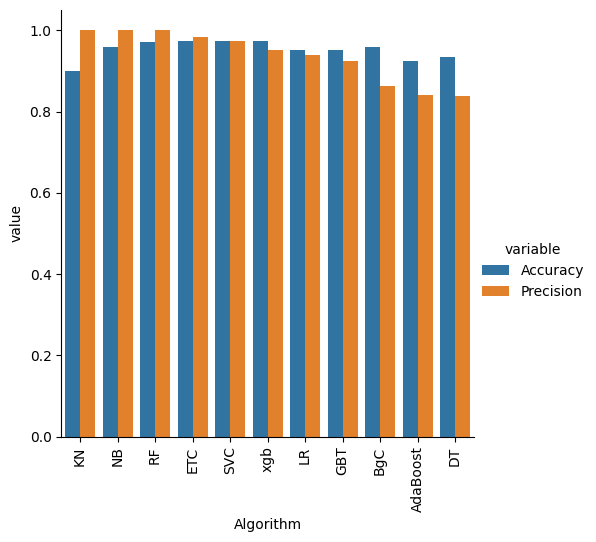

In [ ]:
# sns.catplot(x = 'Algorithm', y = 'value' ,
# hue = 'variable' , data=performance_df.melt(id_vars='Algorithm'),
# kind = 'bar' , height=5)
# plt.xticks(rotation = 'vertical')
# plt.show( )

In [265]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()

def train_classifier(X_train, y_train, X_test, y_test):
    mnb.fit(X_train, y_train)
    y_pred = mnb.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

train_classifier(X_train, y_train, X_test, y_test)

(0.9593810444874274, 1.0)

In [ ]:
import pickle

# Save the Multinomial Naive Bayes model
pickle.dump(mnb, open('model.pkl', 'wb'))

# Save the CountVectorizer
pickle.dump(cv, open('vectorizer.pkl', 'wb'))
